# Plant Disease Prediction

## Importing Dataset

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 140590 files belonging to 38 classes.


### Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 35144 files belonging to 38 classes.


In [42]:
AUTOTUNE = tf.data.AUTOTUNE 

training_set = training_set.prefetch(AUTOTUNE)
validation_set = validation_set.prefetch(AUTOTUNE)

#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [21]:
import tensorflow as tf

fast_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax')
])

print("fast_cnn created successfully")

fast_cnn created successfully


### Building Convolution Layer

In [6]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

ValueError: Input 0 with name 'None' of layer 'conv2d_4' is incompatible with the layer: expected min_ndim=4, found ndim=2. Full shape received: (None, 38)

In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [7]:
cnn.add(tf.keras.layers.Dropout(0.25))

ValueError: Input 0 with name 'None' of layer 'conv2d_4' is incompatible with the layer: expected min_ndim=4, found ndim=2. Full shape received: (None, 38)

In [8]:
cnn.add(tf.keras.layers.Flatten())

ValueError: Input 0 with name 'None' of layer 'conv2d_4' is incompatible with the layer: expected min_ndim=4, found ndim=2. Full shape received: (None, 38)

In [13]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [14]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [15]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

### Compiling and Training Phase

In [22]:
fast_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,854 (464.27 KB)

 Trainable params: 118,854 (464.27 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
training_history = fast_cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10,
    initial_epoch=3
)

Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 236s 108ms/step - accuracy: 0.8690 - loss: 0.4187 - val_accuracy: 0.8731 - val_loss: 0.4071
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 239s 109ms/step - accuracy: 0.8942 - loss: 0.3339 - val_accuracy: 0.8787 - val_loss: 0.3711
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 241s 110ms/step - accuracy: 0.9122 - loss: 0.2786 - val_accuracy: 0.8902 - val_loss: 0.3388
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 250s 114ms/step - accuracy: 0.9250 - loss: 0.2357 - val_accuracy: 0.9236 - val_loss: 0.2438
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 244s 111ms/step - accuracy: 0.9345 - loss: 0.2045 - val_accuracy: 0.9273 - val_loss: 0.2261
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 244s 111ms/step - accuracy: 0.9420 - loss: 0.1799 - val_accuracy: 0.9318 - val_loss: 0.2145
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 245s 112ms/step - accuracy: 0.9484 - loss: 0.1602 - val_accuracy: 0.9294 - val_loss: 0.2187


## Evaluating Model

In [27]:
# Training set Accuracy
train_loss, train_acc = fast_cnn.evaluate(training_set)

print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9441 - loss: 0.1704
Training accuracy: 0.9441496729850769


In [28]:
#Validation set Accuracy
val_loss, val_acc = fast_cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9294 - loss: 0.2187
Validation accuracy: 0.9294331669807434


### Saving Model

In [29]:
fast_cnn.save("plant_disease_model.keras")

In [30]:
training_history.history #Return Dictionary of history

{'accuracy': [0.8689665198326111,
  0.8942385911941528,
  0.9121986031532288,
  0.9250159859657288,
  0.9344618916511536,
  0.9420229196548462,
  0.9483533501625061],
 'loss': [0.41868138313293457,
  0.3339359164237976,
  0.27862128615379333,
  0.2357134222984314,
  0.20453059673309326,
  0.17988015711307526,
  0.16018566489219666],
 'val_accuracy': [0.8730935454368591,
  0.8787274956703186,
  0.890166163444519,
  0.9236285090446472,
  0.9272706508636475,
  0.9318233728408813,
  0.9294331669807434],
 'val_loss': [0.40714290738105774,
  0.3711105287075043,
  0.33878135681152344,
  0.2438233494758606,
  0.22608359158039093,
  0.2145339548587799,
  0.21866728365421295]}

In [31]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [32]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

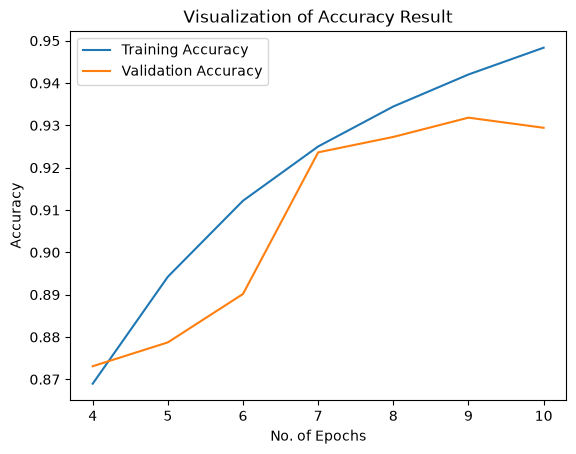

In [34]:
epochs = range(4, 11)

plt.plot(
    epochs,
    training_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    epochs,
    training_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [44]:
import os

class_name = sorted([
    d for d in os.listdir("valid")
    if os.path.isdir(os.path.join("valid", d))
])

print("Number of classes:", len(class_name))
print(class_name)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [45]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 35144 files belonging to 38 classes.


In [55]:
y_pred = fast_cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

35144/35144 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step


In [56]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [57]:
Y_true

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(35144,))>

In [58]:
predicted_categories

<tf.Tensor: shape=(35144,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(35144,))>

In [59]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [61]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.94      0.95      1008
                                 Apple___Black_rot       0.96      0.99      0.97       994
                          Apple___Cedar_apple_rust       0.94      0.97      0.96       880
                                   Apple___healthy       0.98      0.89      0.93      1004
                               Blueberry___healthy       0.92      0.97      0.94       908
          Cherry_(including_sour)___Powdery_mildew       0.97      0.97      0.97       842
                 Cherry_(including_sour)___healthy       0.95      0.98      0.96       912
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.85      0.91       820
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       954
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.99      0.

### Confusion Matrix Visualization

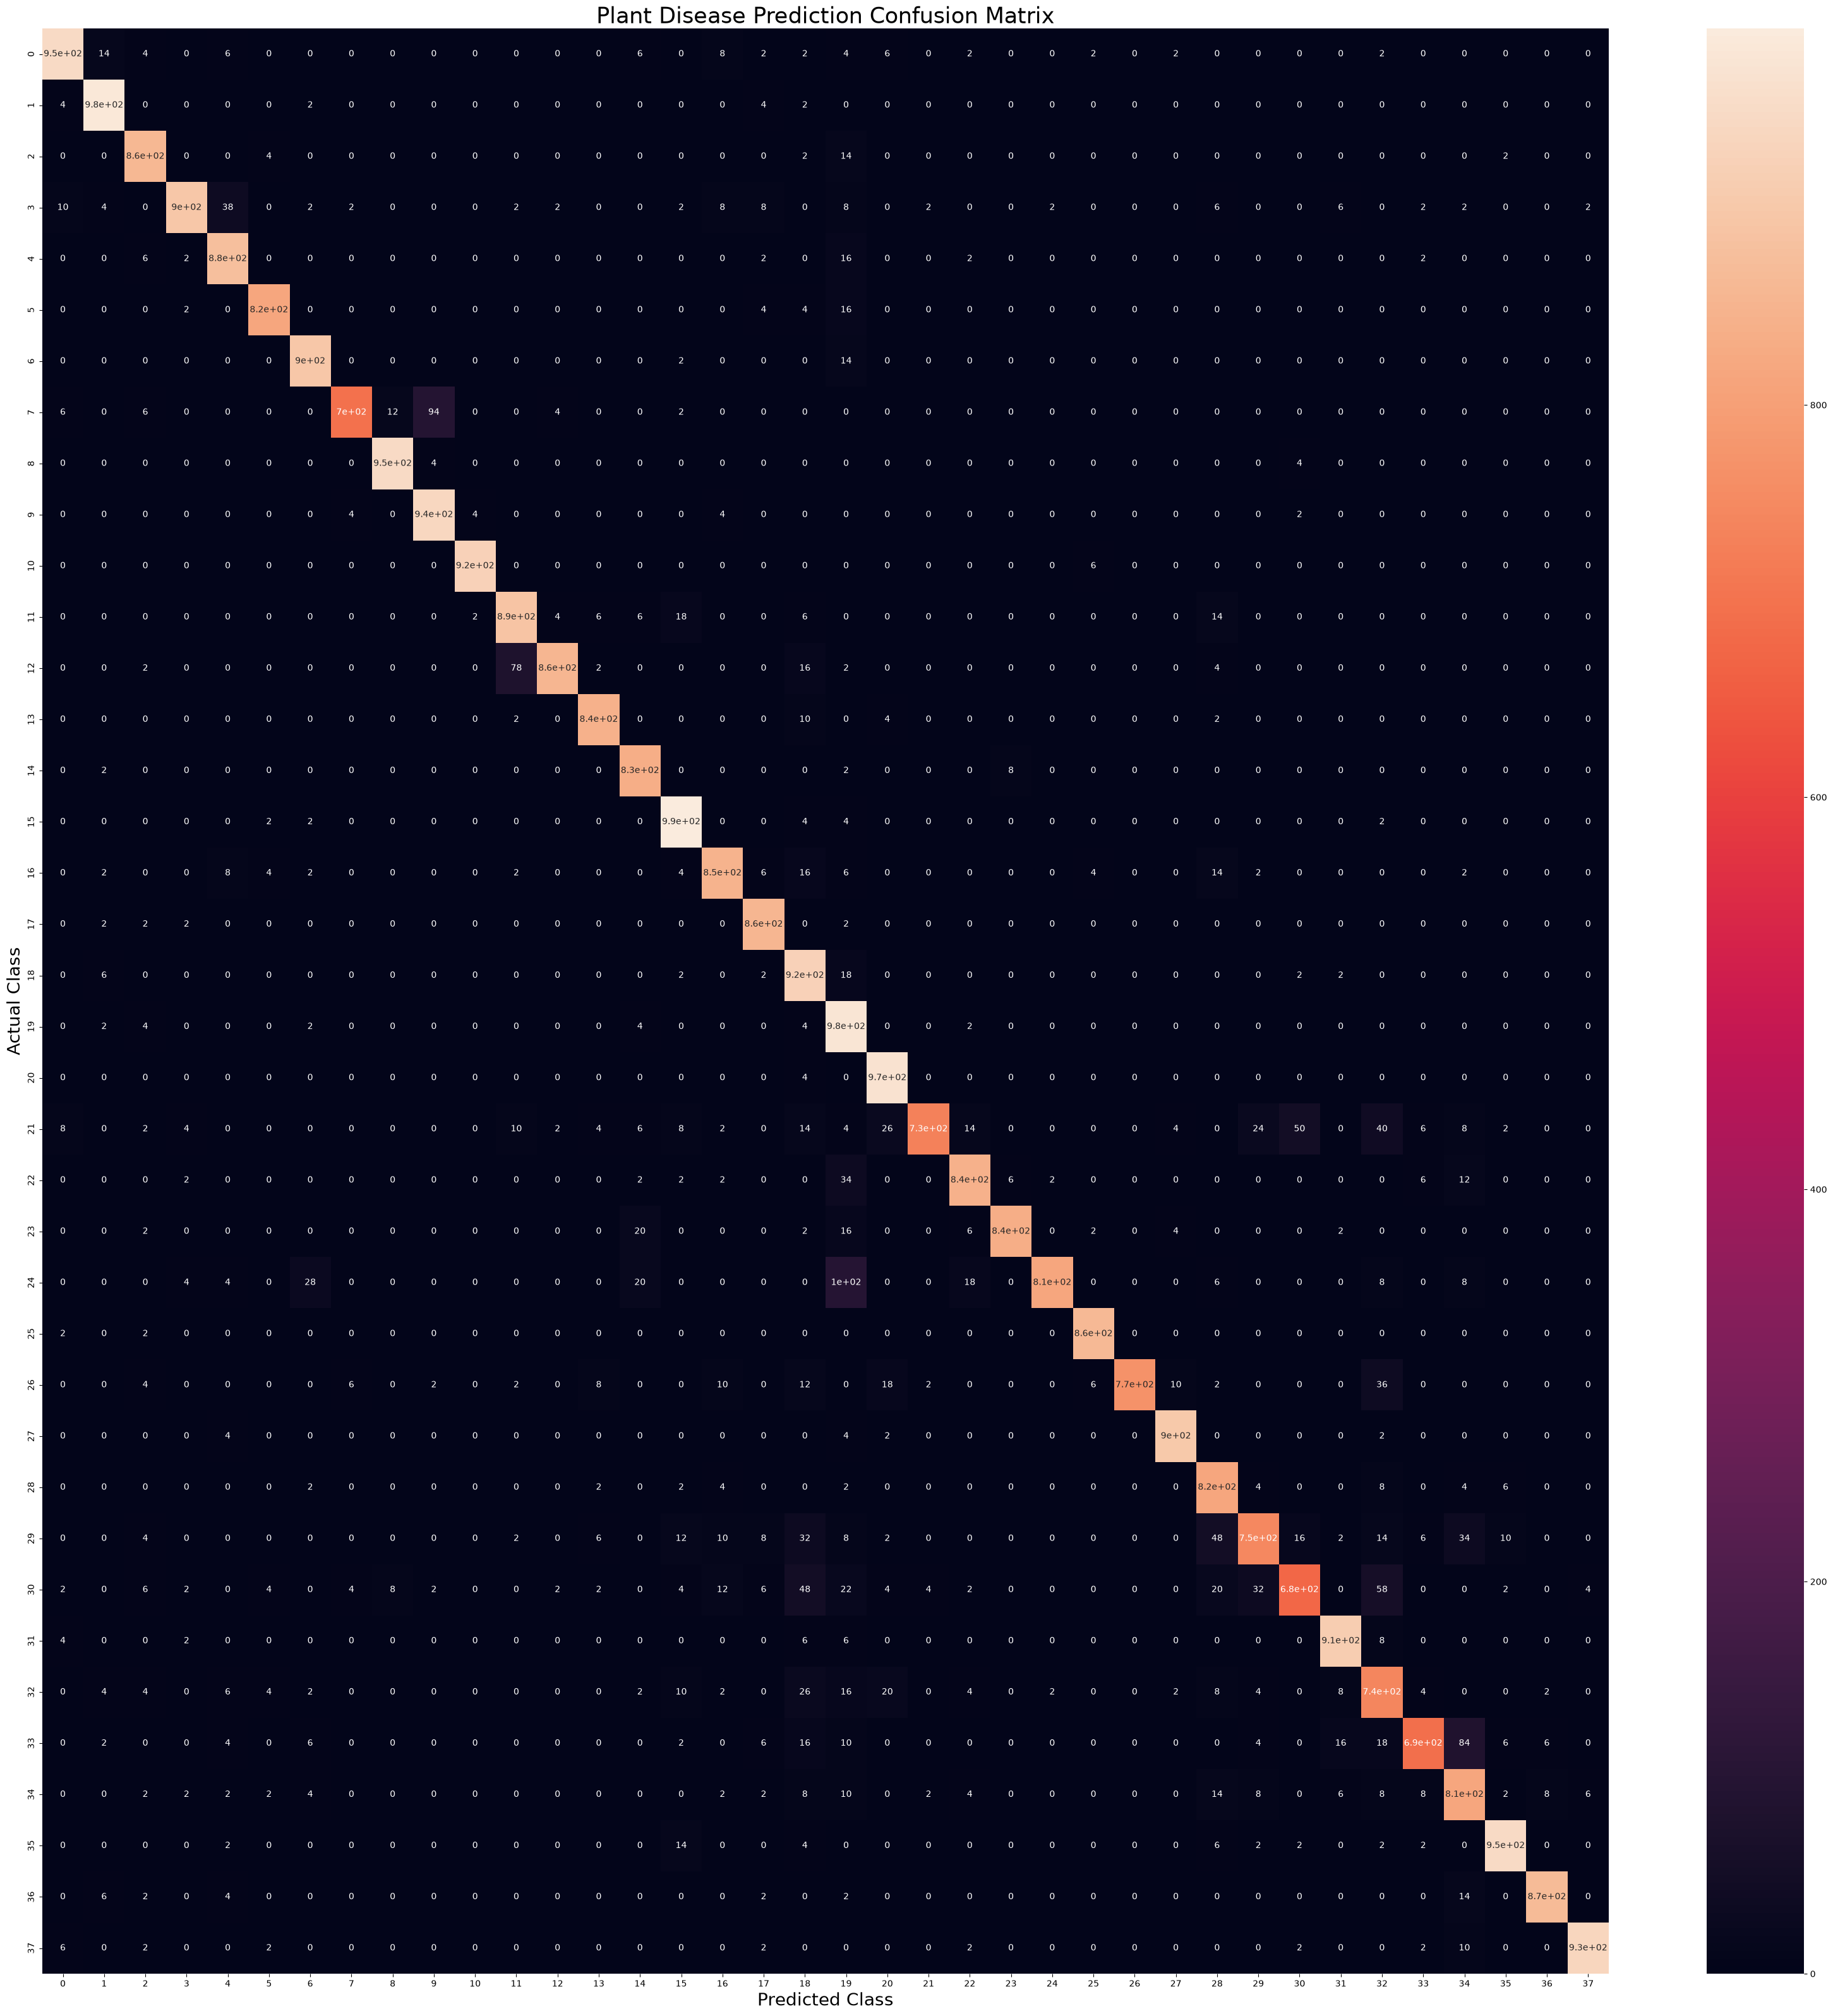

In [62]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()